# Cross-Model Feature Importance for Type 2 Diabetes Prediction
## Complete Pipeline — Preprocessing + KNN + Logistic Regression + ANN

**INFO 5368 · Cornell Tech**

This notebook is the single end-to-end pipeline:

1. **Preprocessing** — load CDC BRFSS 2015 dataset, EDA, BMI outlier removal, drop highly-correlated features, stratified split, min-max normalization.
2. **Model implementations** — KNN, Logistic Regression, and ANN (1-layer + 2-layer) — all NumPy-only, copied verbatim from the project's `.py` modules so this notebook is self-contained.
3. **Training** — each model has a `RETRAIN_*` flag at the top of its section. By default the notebook **skips training and reuses cached `models/*.npy` artifacts** when present, which makes re-execution fast. Set the flag to `True` (or delete the artifacts) to force a fresh run.
4. **Evaluation + plots** — confusion matrix, ROC curve, and top-10 permutation feature importance for each model, in a unified visual style.
5. **Cross-model comparison** — side-by-side metrics, ROC overlay, and feature-importance heatmap.


## 0. Setup

In [1]:
import os
import time
import csv
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Paths & constants ───────────────────────────────────────────────────────

DATA_PATH_BAL  = 'data/diabetes_binary_5050split_health_indicators_BRFSS2015.csv'
DATA_PATH_FULL = 'data/diabetes_binary_health_indicators_BRFSS2015.csv'
MODELS_DIR     = 'models'

TARGET_COL = 'Diabetes_binary'
RANDOM_SEED = 42
TEST_SIZE   = 0.2
CORR_THRESHOLD = 0.7

BINARY_FEATURES = [
    'HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke',
    'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
    'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex',
]
ORDINAL_FEATURES   = ['GenHlth', 'Age', 'Education', 'Income']
NUMERICAL_FEATURES = ['BMI', 'MentHlth', 'PhysHlth']
ALL_FEATURES = BINARY_FEATURES + ORDINAL_FEATURES + NUMERICAL_FEATURES   # 21 features

# ── Unified plot style ──────────────────────────────────────────────────────

plt.rcParams.update({
    'figure.dpi':         100,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          False,
    'font.size':          10,
    'axes.titlesize':     12,
    'axes.labelsize':     11,
    'legend.fontsize':    9,
    'xtick.labelsize':    9,
    'ytick.labelsize':    9,
})

# Per-model colour palette (used everywhere for consistency)
PALETTE = {
    'logreg':    '#3F8F2E',   # green
    'knn':       '#378ADD',   # blue
    'ann':       '#E24B4A',   # red
    'pos':       '#378ADD',   # blue (positive importance)
    'neg':       '#E24B4A',   # red  (negative importance)
    'ref':       'gray',
    'fill':      'steelblue',
    'cm_cmap':   'Blues',
    'corr_cmap': 'RdBu_r',
    'grid_cmap': 'viridis',
}

os.makedirs(MODELS_DIR, exist_ok=True)
np.random.seed(RANDOM_SEED)
print('Setup done.')


Setup done.


## 1. Data Preprocessing

### 1.1 Preprocessing functions (copied from `preprocess.py`)

In [2]:
def _resolve_dataset_path(path: str) -> str:
    """Resolve the dataset path, falling back to common alternatives."""
    for candidate in [path, DATA_PATH_FULL]:
        if os.path.exists(candidate):
            return candidate
    if os.path.isdir('data'):
        csvs = sorted(f for f in os.listdir('data') if f.lower().endswith('.csv'))
        if csvs:
            auto = os.path.join('data', csvs[0])
            print(f'[preprocess] Using detected dataset: {auto!r}')
            return auto
    raise FileNotFoundError(
        f'Dataset not found. Tried {path!r} and {DATA_PATH_FULL!r}.'
        ' Download the CSV from Kaggle and place it in ./data/.'
    )


def load_data(path: str = DATA_PATH_BAL) -> pd.DataFrame:
    resolved = _resolve_dataset_path(path)
    df = pd.read_csv(resolved)
    print(f'[load] {len(df):,} rows × {df.shape[1]} cols  ({resolved})')
    return df


def remove_bmi_outliers(df: pd.DataFrame) -> pd.DataFrame:
    if 'BMI' not in df.columns:
        return df
    Q1, Q3 = df['BMI'].quantile(0.25), df['BMI'].quantile(0.75)
    IQR = Q3 - Q1
    before = len(df)
    df = df[(df['BMI'] >= Q1 - 1.5 * IQR) & (df['BMI'] <= Q3 + 1.5 * IQR)]
    print(f'[preprocess] BMI outlier removal: {before:,} → {len(df):,} rows')
    return df


def remove_correlated_features(df: pd.DataFrame, threshold: float = CORR_THRESHOLD):
    corr = df[ALL_FEATURES].corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [c for c in upper.columns if any(upper[c] > threshold)]
    if to_drop:
        print(f'[preprocess] Dropping correlated features: {to_drop}')
    else:
        print('[preprocess] No features dropped (no |r| > 0.7 pair)')
    return df.drop(columns=to_drop), to_drop


def minmax_normalize(X, feature_min=None, feature_max=None):
    if feature_min is None:
        feature_min = X.min(axis=0)
    if feature_max is None:
        feature_max = X.max(axis=0)
    denom = feature_max - feature_min
    denom[denom == 0] = 1
    return (X - feature_min) / denom, feature_min, feature_max


def stratified_train_test_split(X, y, test_size=TEST_SIZE, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    train_idx, test_idx = [], []
    for cls in np.unique(y):
        idx = np.where(y == cls)[0]
        rng.shuffle(idx)
        n_test = int(len(idx) * test_size)
        test_idx.extend(idx[:n_test].tolist())
        train_idx.extend(idx[n_test:].tolist())
    train_idx, test_idx = np.array(train_idx), np.array(test_idx)
    rng.shuffle(train_idx)
    rng.shuffle(test_idx)
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]


def preprocess_pipeline(path: str = DATA_PATH_BAL, save: bool = True):
    df = load_data(path)
    df = remove_bmi_outliers(df)
    df, _ = remove_correlated_features(df)

    available = [f for f in ALL_FEATURES if f in df.columns]
    X = df[available].values.astype(np.float64)
    y = df[TARGET_COL].values.astype(np.float64)

    X_train, X_test, y_train, y_test = stratified_train_test_split(X, y)
    X_train, feat_min, feat_max = minmax_normalize(X_train)
    X_test,  _, _               = minmax_normalize(X_test, feat_min, feat_max)

    if save:
        os.makedirs(MODELS_DIR, exist_ok=True)
        np.save(f'{MODELS_DIR}/X_train.npy',       X_train)
        np.save(f'{MODELS_DIR}/X_test.npy',        X_test)
        np.save(f'{MODELS_DIR}/y_train.npy',       y_train)
        np.save(f'{MODELS_DIR}/y_test.npy',        y_test)
        np.save(f'{MODELS_DIR}/feat_min.npy',      feat_min)
        np.save(f'{MODELS_DIR}/feat_max.npy',      feat_max)
        np.save(f'{MODELS_DIR}/feature_names.npy', np.array(available))
        print(f'[preprocess] Saved splits + scaler to {MODELS_DIR}/')

    return X_train, X_test, y_train, y_test, available, {'min': feat_min, 'max': feat_max}


def load_preprocessed():
    X_train = np.load(f'{MODELS_DIR}/X_train.npy')
    X_test  = np.load(f'{MODELS_DIR}/X_test.npy')
    y_train = np.load(f'{MODELS_DIR}/y_train.npy')
    y_test  = np.load(f'{MODELS_DIR}/y_test.npy')
    feat_min = np.load(f'{MODELS_DIR}/feat_min.npy')
    feat_max = np.load(f'{MODELS_DIR}/feat_max.npy')
    feature_names = np.load(f'{MODELS_DIR}/feature_names.npy', allow_pickle=True).tolist()
    return X_train, X_test, y_train, y_test, feature_names, {'min': feat_min, 'max': feat_max}


### 1.2 Run pipeline (or load cached splits)

Set `RERUN_PREPROCESS = True` to force a fresh pass over the raw CSV.


In [3]:
RERUN_PREPROCESS = False

required = [
    f'{MODELS_DIR}/X_train.npy',  f'{MODELS_DIR}/X_test.npy',
    f'{MODELS_DIR}/y_train.npy',  f'{MODELS_DIR}/y_test.npy',
    f'{MODELS_DIR}/feat_min.npy', f'{MODELS_DIR}/feat_max.npy',
    f'{MODELS_DIR}/feature_names.npy',
]
cached_ok = (not RERUN_PREPROCESS) and all(os.path.exists(p) for p in required)

if cached_ok:
    print('[skip] Loading cached preprocessed splits ...')
    X_train, X_test, y_train, y_test, feature_names, scaler = load_preprocessed()
else:
    print('[run]  Re-running preprocess pipeline ...')
    X_train, X_test, y_train, y_test, feature_names, scaler = preprocess_pipeline()

print()
print(f'X_train: {X_train.shape}    X_test: {X_test.shape}')
print(f'Train balance — 0:{(y_train==0).sum():,}  1:{(y_train==1).sum():,}')
print(f'Test  balance — 0:{(y_test==0).sum():,}   1:{(y_test==1).sum():,}')
print(f'Features ({len(feature_names)}): {feature_names}')


[skip] Loading cached preprocessed splits ...

X_train: (54810, 21)    X_test: (13701, 21)
Train balance — 0:27,888  1:26,922
Test  balance — 0:6,971   1:6,730
Features (21): ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex', 'GenHlth', 'Age', 'Education', 'Income', 'BMI', 'MentHlth', 'PhysHlth']


### 1.3 EDA — class distribution + numerical features

[load] 70,692 rows × 22 cols  (data/diabetes_binary_5050split_health_indicators_BRFSS2015.csv)
Class distribution (raw): {0: 35346, 1: 35346}
Missing values:           0


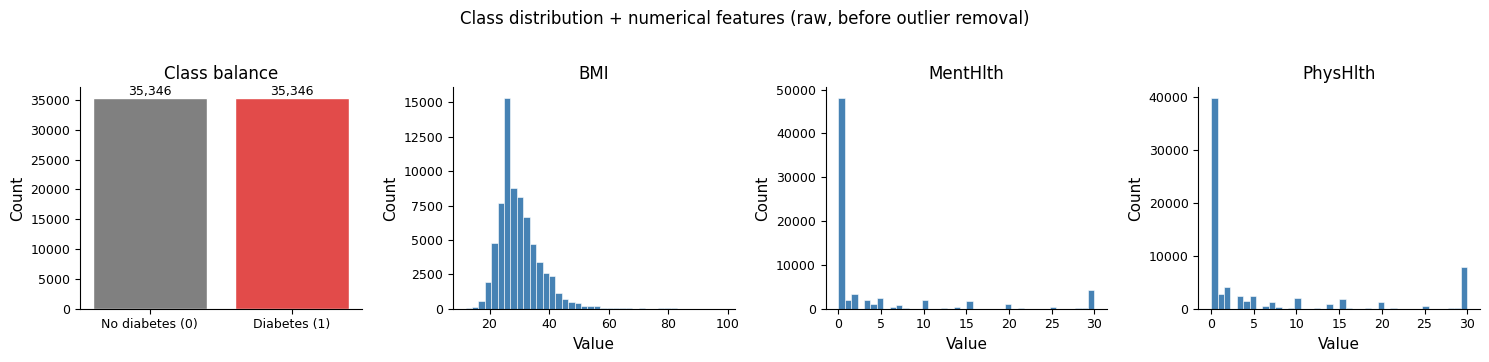

In [4]:
# Reload the *raw* CSV just for EDA visuals (preprocessed splits are normalised).
df_raw = load_data()

counts = Counter(df_raw[TARGET_COL].astype(int))
print(f'Class distribution (raw): {dict(counts)}')
print(f'Missing values:           {int(df_raw.isnull().sum().sum())}')

fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))

# Class balance bar
ax = axes[0]
ax.bar(['No diabetes (0)', 'Diabetes (1)'],
       [counts[0], counts[1]],
       color=[PALETTE['ref'], PALETTE['ann']], edgecolor='white')
for i, v in enumerate([counts[0], counts[1]]):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)
ax.set_title('Class balance')
ax.set_ylabel('Count')

# Numerical features
for ax, col in zip(axes[1:], NUMERICAL_FEATURES):
    ax.hist(df_raw[col], bins=40, color=PALETTE['fill'], edgecolor='white', linewidth=0.4)
    ax.set_title(col)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

plt.suptitle('Class distribution + numerical features (raw, before outlier removal)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


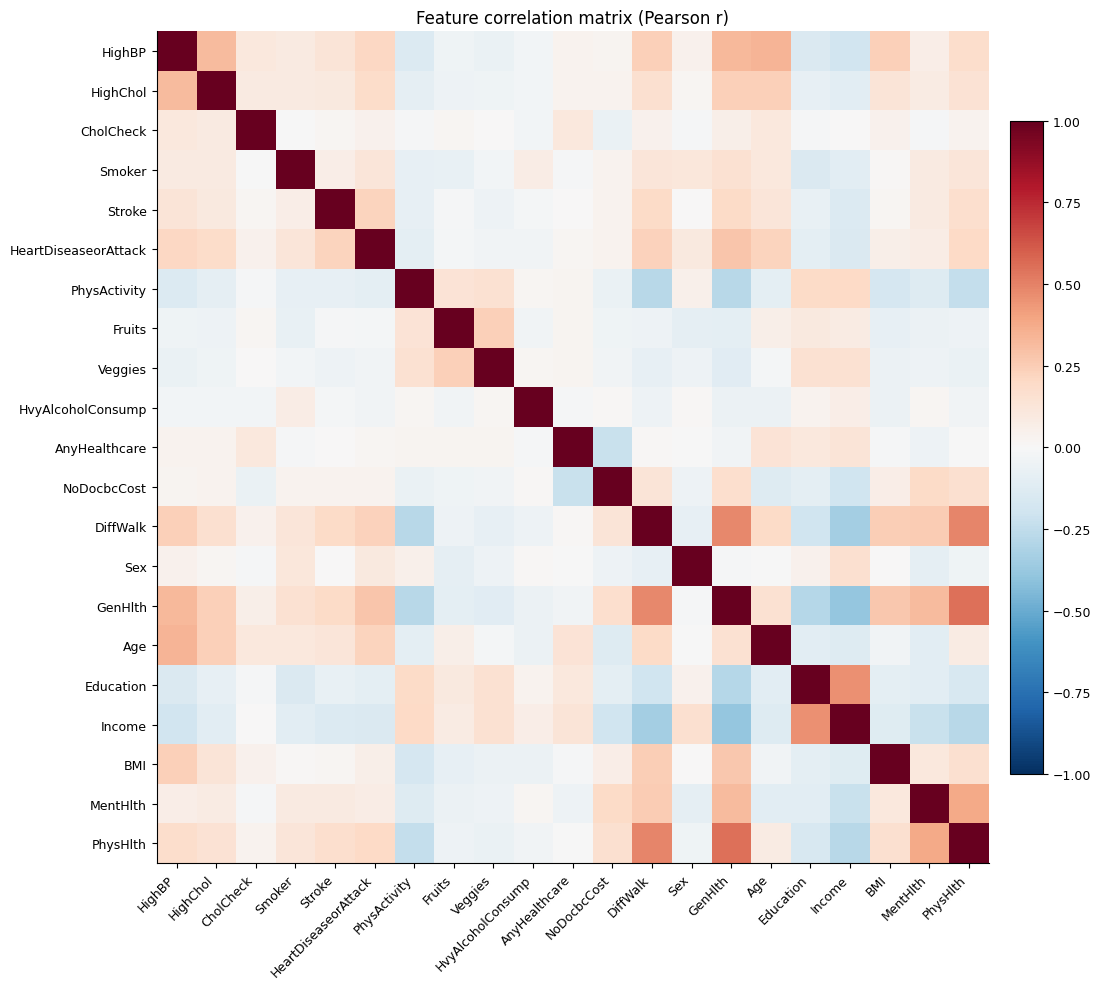

Max |r| off-diagonal: 0.553 — drop threshold = 0.7


In [5]:
# Correlation heatmap of all 21 input features
corr = df_raw[ALL_FEATURES].corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr, cmap=PALETTE['corr_cmap'], vmin=-1, vmax=1)
ax.set_xticks(range(len(ALL_FEATURES)))
ax.set_yticks(range(len(ALL_FEATURES)))
ax.set_xticklabels(ALL_FEATURES, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ALL_FEATURES, fontsize=9)
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
ax.set_title('Feature correlation matrix (Pearson r)')
plt.tight_layout()
plt.show()

mask = ~np.eye(len(corr), dtype=bool)
print(f'Max |r| off-diagonal: {corr.where(mask).abs().max().max():.3f}'
      f' — drop threshold = {CORR_THRESHOLD}')


## 2. Model Implementations

All three models are implemented in pure NumPy. The cells below are **copied verbatim** from `knn_model.py`, `logistic_regression.py`, and `ann_model.py` so this notebook does not depend on the `.py` modules at runtime.


### 2.1 KNN (`knn_model.py`)

In [6]:
class KNN:
    """K-Nearest Neighbours, NumPy-only, with batched distance compute."""

    def __init__(self, num_neighbors: int = 5, metric: str = 'Euclidean'):
        self.model_name    = 'K Nearest Neighbor'
        self.num_neighbors = num_neighbors
        self.metric        = metric
        self.X_train       = None
        self.y_train       = None

    def euclidean_distance(self, feature_matrix, query):
        return np.sqrt(np.sum((feature_matrix - query) ** 2, axis=1))

    def manhattan_distance(self, feature_matrix, query):
        return np.sum(np.abs(feature_matrix - query), axis=1)

    def _batch_distances(self, X_train, X_query):
        """||a-b||² = ||a||² + ||b||² - 2·a·b^T (Euclidean only)."""
        if self.metric == 'Euclidean':
            train_sq = np.sum(X_train ** 2, axis=1)
            query_sq = np.sum(X_query ** 2, axis=1)
            cross    = X_query @ X_train.T
            dist_sq  = query_sq[:, None] + train_sq[None, :] - 2 * cross
            return np.sqrt(np.maximum(dist_sq, 0))
        # Manhattan: per-query loop is still fast because vectorised inside
        dists = np.empty((len(X_query), len(X_train)), dtype=np.float64)
        for i, q in enumerate(X_query):
            dists[i] = self.manhattan_distance(X_train, q)
        return dists

    def fit(self, X_train, y_train):
        self.X_train = X_train
        self.y_train = y_train

    def predict(self, X_query, batch_size: int = 512):
        assert self.X_train is not None, 'Call fit() before predict().'
        n = len(X_query)
        out = np.empty(n, dtype=np.float64)
        for start in range(0, n, batch_size):
            end   = min(start + batch_size, n)
            batch = X_query[start:end]
            dists = self._batch_distances(self.X_train, batch)
            k_idx    = np.argpartition(dists, self.num_neighbors, axis=1)[:, :self.num_neighbors]
            k_labels = self.y_train[k_idx]
            out[start:end] = (k_labels.mean(axis=1) >= 0.5).astype(np.float64)
        return out

    def predict_proba(self, X_query, batch_size: int = 512):
        assert self.X_train is not None, 'Call fit() before predict_proba().'
        n = len(X_query)
        proba = np.empty(n, dtype=np.float64)
        for start in range(0, n, batch_size):
            end   = min(start + batch_size, n)
            batch = X_query[start:end]
            dists = self._batch_distances(self.X_train, batch)
            k_idx = np.argpartition(dists, self.num_neighbors, axis=1)[:, :self.num_neighbors]
            proba[start:end] = self.y_train[k_idx].mean(axis=1)
        return proba


### 2.2 Logistic Regression (`logistic_regression.py`)

In [7]:
class LogisticRegression:
    """Batch gradient-descent logistic regression with L2 + early stopping."""

    def __init__(self, learning_rate=0.01, n_iterations=1000, lambda_reg=0.01,
                 early_stopping=True, patience=20):
        self.model_name     = 'Logistic Regression'
        self.lr             = learning_rate
        self.n_iter         = n_iterations
        self.lambda_reg     = lambda_reg
        self.early_stopping = early_stopping
        self.patience       = patience
        self.w = None
        self.b = None
        self.train_loss_history = []
        self.val_loss_history   = []

    def _sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z))

    def _bce_loss(self, y_true, y_pred):
        eps = 1e-15
        y_pred = np.clip(y_pred, eps, 1 - eps)
        loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
        if self.lambda_reg > 0 and self.w is not None:
            loss += (self.lambda_reg / 2) * np.sum(self.w ** 2)
        return loss

    def fit(self, X_train, y_train, X_val=None, y_val=None):
        n_samples, n_features = X_train.shape
        self.w = np.zeros(n_features)
        self.b = 0.0

        best_val_loss = float('inf')
        best_w, best_b = self.w.copy(), self.b
        epochs_no_improve = 0

        for _ in range(self.n_iter):
            z      = X_train @ self.w + self.b
            y_pred = self._sigmoid(z)
            error  = y_pred - y_train
            dw = (X_train.T @ error) / n_samples + self.lambda_reg * self.w
            db = np.mean(error)
            self.w -= self.lr * dw
            self.b -= self.lr * db
            self.train_loss_history.append(self._bce_loss(y_train, y_pred))

            if X_val is not None and y_val is not None:
                val_pred = self._sigmoid(X_val @ self.w + self.b)
                val_loss = self._bce_loss(y_val, val_pred)
                self.val_loss_history.append(val_loss)
                if self.early_stopping:
                    if val_loss < best_val_loss:
                        best_val_loss = val_loss
                        best_w, best_b = self.w.copy(), self.b
                        epochs_no_improve = 0
                    else:
                        epochs_no_improve += 1
                        if epochs_no_improve >= self.patience:
                            self.w, self.b = best_w, best_b
                            break
        return self

    def predict_proba(self, X_query):
        assert self.w is not None, 'Call fit() before predict_proba().'
        return self._sigmoid(X_query @ self.w + self.b)

    def predict(self, X_query, threshold: float = 0.5):
        return (self.predict_proba(X_query) >= threshold).astype(np.float64)


### 2.3 ANN — 1-layer + 2-layer (`ann_model.py`)

Architecture:

$$h = \mathrm{ReLU}(W_1 x + b_1), \quad \hat{y} = \sigma(W_2 h + b_2) \quad\text{(1-layer)}$$

$$h_1 = \mathrm{ReLU}(W_1 x + b_1), \; h_2 = \mathrm{ReLU}(W_2 h_1 + b_2), \; \hat{y} = \sigma(W_3 h_2 + b_3) \quad\text{(2-layer)}$$

Loss is BCE-with-logits (numerically stable) and the optimiser is Adam, both implemented from scratch in NumPy. Regularisation = L2 weight decay + early stopping.


In [8]:
SEED = RANDOM_SEED


def stable_sigmoid(z):
    z = np.asarray(z, dtype=np.float64)
    out = np.empty_like(z)
    pos = z >= 0
    out[pos]  = 1.0 / (1.0 + np.exp(-z[pos]))
    exp_z     = np.exp(z[~pos])
    out[~pos] = exp_z / (1.0 + exp_z)
    return out


def bce_with_logits(logits, y):
    """max(z, 0) - z·y + log1p(exp(-|z|))  (numerically stable BCE)."""
    return float(np.mean(
        np.maximum(logits, 0.0) - logits * y + np.log1p(np.exp(-np.abs(logits)))
    ))


class AdamOptimizer:
    def __init__(self, param_shapes, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr, self.beta1, self.beta2, self.eps = lr, beta1, beta2, eps
        self.t = 0
        self.m = {k: np.zeros(s, dtype=np.float64) for k, s in param_shapes.items()}
        self.v = {k: np.zeros(s, dtype=np.float64) for k, s in param_shapes.items()}

    def step(self, params, grads):
        self.t += 1
        bc1 = 1.0 - self.beta1 ** self.t
        bc2 = 1.0 - self.beta2 ** self.t
        for k in params:
            g = grads[k]
            self.m[k] = self.beta1 * self.m[k] + (1.0 - self.beta1) * g
            self.v[k] = self.beta2 * self.v[k] + (1.0 - self.beta2) * (g * g)
            m_hat = self.m[k] / bc1
            v_hat = self.v[k] / bc2
            params[k] -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)


In [9]:
class ANNNet:
    """1-hidden-layer feedforward network with He init (proposal Eq. 5)."""

    def __init__(self, input_dim, hidden_dim=64, seed=SEED):
        rng = np.random.default_rng(seed)
        self.params = {
            'W1': rng.standard_normal((input_dim, hidden_dim)) * np.sqrt(2.0 / input_dim),
            'b1': np.zeros(hidden_dim,  dtype=np.float64),
            'W2': rng.standard_normal((hidden_dim, 1))         * np.sqrt(2.0 / hidden_dim),
            'b2': np.zeros(1,           dtype=np.float64),
        }

    @property
    def param_shapes(self):
        return {k: v.shape for k, v in self.params.items()}

    def forward(self, X):
        z1 = X @ self.params['W1'] + self.params['b1']
        h  = np.maximum(0.0, z1)
        z2 = h @ self.params['W2'] + self.params['b2']
        return z2.squeeze(-1), {'X': X, 'z1': z1, 'h': h}

    def backward(self, cache, y, logits, weight_decay=0.0):
        X, z1, h = cache['X'], cache['z1'], cache['h']
        N = X.shape[0]
        dz2 = (stable_sigmoid(logits) - y)[:, None] / N
        dW2 = h.T @ dz2
        db2 = dz2.sum(axis=0)
        dh  = dz2 @ self.params['W2'].T
        dz1 = dh * (z1 > 0)
        dW1 = X.T @ dz1
        db1 = dz1.sum(axis=0)
        if weight_decay > 0:
            dW1 += weight_decay * self.params['W1']
            dW2 += weight_decay * self.params['W2']
        return {'W1': dW1, 'b1': db1, 'W2': dW2, 'b2': db2}

    def state_dict(self):
        return {k: v.copy() for k, v in self.params.items()}

    def load_state_dict(self, state):
        for k in self.params:
            self.params[k] = state[k].copy()


class ANNNet2:
    """2-hidden-layer feedforward network (extension beyond proposal Eq. 5)."""

    def __init__(self, input_dim, hidden_dims=(128, 64), seed=SEED):
        rng = np.random.default_rng(seed)
        h1, h2 = hidden_dims
        self.params = {
            'W1': rng.standard_normal((input_dim, h1)) * np.sqrt(2.0 / input_dim),
            'b1': np.zeros(h1, dtype=np.float64),
            'W2': rng.standard_normal((h1, h2))        * np.sqrt(2.0 / h1),
            'b2': np.zeros(h2, dtype=np.float64),
            'W3': rng.standard_normal((h2, 1))         * np.sqrt(2.0 / h2),
            'b3': np.zeros(1,  dtype=np.float64),
        }

    @property
    def param_shapes(self):
        return {k: v.shape for k, v in self.params.items()}

    def forward(self, X):
        z1 = X @ self.params['W1'] + self.params['b1']; h1 = np.maximum(0.0, z1)
        z2 = h1 @ self.params['W2'] + self.params['b2']; h2 = np.maximum(0.0, z2)
        z3 = h2 @ self.params['W3'] + self.params['b3']
        return z3.squeeze(-1), {'X': X, 'z1': z1, 'h1': h1, 'z2': z2, 'h2': h2}

    def backward(self, cache, y, logits, weight_decay=0.0):
        X = cache['X']; z1, h1, z2, h2 = cache['z1'], cache['h1'], cache['z2'], cache['h2']
        N = X.shape[0]
        dz3 = (stable_sigmoid(logits) - y)[:, None] / N
        dW3 = h2.T @ dz3;  db3 = dz3.sum(axis=0)
        dh2 = dz3 @ self.params['W3'].T;  dz2 = dh2 * (z2 > 0)
        dW2 = h1.T @ dz2;  db2 = dz2.sum(axis=0)
        dh1 = dz2 @ self.params['W2'].T;  dz1 = dh1 * (z1 > 0)
        dW1 = X.T @ dz1;   db1 = dz1.sum(axis=0)
        if weight_decay > 0:
            dW1 += weight_decay * self.params['W1']
            dW2 += weight_decay * self.params['W2']
            dW3 += weight_decay * self.params['W3']
        return {'W1': dW1, 'b1': db1, 'W2': dW2, 'b2': db2, 'W3': dW3, 'b3': db3}

    def state_dict(self):
        return {k: v.copy() for k, v in self.params.items()}

    def load_state_dict(self, state):
        for k in self.params:
            self.params[k] = state[k].copy()


In [10]:
class _ANNBase:
    """Shared mini-batch Adam training loop for ANN / ANN2."""

    def fit(self, X_train, y_train, X_val=None, y_val=None):
        optim = AdamOptimizer(self.net.param_shapes, lr=self.lr)
        rng   = np.random.default_rng(self.seed)
        X_tr  = np.asarray(X_train, dtype=np.float64)
        y_tr  = np.asarray(y_train, dtype=np.float64)
        N     = X_tr.shape[0]

        has_val = X_val is not None and y_val is not None
        if has_val:
            X_v = np.asarray(X_val, dtype=np.float64)
            y_v = np.asarray(y_val, dtype=np.float64)

        best_val_loss = float('inf')
        best_state = None
        epochs_no_improve = 0

        for epoch in range(self.epochs):
            perm = rng.permutation(N)
            epoch_loss, n_seen = 0.0, 0
            for start in range(0, N, self.batch_size):
                idx = perm[start:start + self.batch_size]
                xb, yb = X_tr[idx], y_tr[idx]
                logits, cache = self.net.forward(xb)
                loss = bce_with_logits(logits, yb)
                grads = self.net.backward(cache, yb, logits, self.weight_decay)
                optim.step(self.net.params, grads)
                epoch_loss += loss * xb.shape[0]
                n_seen     += xb.shape[0]
            self.train_loss_history.append(epoch_loss / n_seen)

            if has_val:
                val_logits, _ = self.net.forward(X_v)
                val_loss = bce_with_logits(val_logits, y_v)
                self.val_loss_history.append(val_loss)
                if self.early_stopping:
                    if val_loss < best_val_loss - 1e-6:
                        best_val_loss = val_loss
                        best_state    = self.net.state_dict()
                        epochs_no_improve = 0
                    else:
                        epochs_no_improve += 1
                        if epochs_no_improve >= self.patience:
                            if self.verbose:
                                print(f'    [early stop] epoch {epoch+1}, '
                                      f'best val_loss={best_val_loss:.4f}')
                            break

            if self.verbose and (epoch + 1) % max(1, self.epochs // 10) == 0:
                tail = f'  val_loss={self.val_loss_history[-1]:.4f}' if has_val else ''
                print(f'    epoch {epoch+1:>3}/{self.epochs}  '
                      f'train_loss={self.train_loss_history[-1]:.4f}{tail}')

        if self.early_stopping and best_state is not None:
            self.net.load_state_dict(best_state)
        return self

    def predict_proba(self, X_query):
        assert self.net is not None, 'Call fit() before predict_proba().'
        logits, _ = self.net.forward(np.asarray(X_query, dtype=np.float64))
        return stable_sigmoid(logits)

    def predict(self, X_query, threshold: float = 0.5):
        return (self.predict_proba(X_query) >= threshold).astype(np.float64)


class ANN(_ANNBase):
    def __init__(self, input_dim, hidden_dim=64, learning_rate=0.01, epochs=100,
                 batch_size=256, weight_decay=1e-4, early_stopping=True, patience=10,
                 seed=SEED, verbose=False):
        self.model_name = 'Artificial Neural Network'
        self.input_dim, self.hidden_dim = input_dim, hidden_dim
        self.lr, self.epochs, self.batch_size = learning_rate, epochs, batch_size
        self.weight_decay = weight_decay
        self.early_stopping, self.patience = early_stopping, patience
        self.seed, self.verbose = seed, verbose
        self.net = ANNNet(input_dim, hidden_dim, seed=seed)
        self.train_loss_history, self.val_loss_history = [], []

    def fit(self, X_train, y_train, X_val=None, y_val=None):
        # re-init weights so each call to .fit() is fresh
        self.net = ANNNet(self.input_dim, self.hidden_dim, seed=self.seed)
        self.train_loss_history, self.val_loss_history = [], []
        return super().fit(X_train, y_train, X_val, y_val)


class ANN2(_ANNBase):
    def __init__(self, input_dim, hidden_dims=(128, 64), learning_rate=0.01, epochs=100,
                 batch_size=256, weight_decay=1e-4, early_stopping=True, patience=10,
                 seed=SEED, verbose=False):
        self.model_name = 'ANN (2 hidden layers)'
        self.input_dim, self.hidden_dims = input_dim, hidden_dims
        self.lr, self.epochs, self.batch_size = learning_rate, epochs, batch_size
        self.weight_decay = weight_decay
        self.early_stopping, self.patience = early_stopping, patience
        self.seed, self.verbose = seed, verbose
        self.net = ANNNet2(input_dim, hidden_dims, seed=seed)
        self.train_loss_history, self.val_loss_history = [], []

    def fit(self, X_train, y_train, X_val=None, y_val=None):
        self.net = ANNNet2(self.input_dim, self.hidden_dims, seed=self.seed)
        self.train_loss_history, self.val_loss_history = [], []
        return super().fit(X_train, y_train, X_val, y_val)


### 2.4 Evaluation helpers (metrics + permutation importance)

In [11]:
def _auc_roc(y_true, y_score):
    """Trapezoidal AUC-ROC, NumPy-only."""
    thresholds = np.sort(np.unique(y_score))[::-1]
    pos = y_true.sum()
    neg = len(y_true) - pos
    tprs, fprs = [0.0], [0.0]
    for t in thresholds:
        pred = (y_score >= t).astype(float)
        tprs.append(np.sum((pred == 1) & (y_true == 1)) / pos)
        fprs.append(np.sum((pred == 1) & (y_true == 0)) / neg)
    tprs.append(1.0); fprs.append(1.0)
    tprs, fprs = np.array(tprs), np.array(fprs)
    trapz = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz
    return float(trapz(tprs, fprs))


def compute_metrics(y_true, y_pred, y_proba=None):
    TP = int(np.sum((y_pred == 1) & (y_true == 1)))
    TN = int(np.sum((y_pred == 0) & (y_true == 0)))
    FP = int(np.sum((y_pred == 1) & (y_true == 0)))
    FN = int(np.sum((y_pred == 0) & (y_true == 1)))
    accuracy  = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    out = dict(accuracy=accuracy, precision=precision, recall=recall, f1=f1,
               TP=TP, TN=TN, FP=FP, FN=FN)
    if y_proba is not None:
        out['auc_roc'] = _auc_roc(y_true, y_proba)
    return out


def print_metrics(m, label=''):
    header = f'── {label} ' if label else '── '
    print(f'\n{header}{"─" * (50 - len(header))}')
    print(f'  Accuracy  : {m["accuracy"]:.4f}')
    print(f'  Precision : {m["precision"]:.4f}')
    print(f'  Recall    : {m["recall"]:.4f}')
    print(f'  F1-Score  : {m["f1"]:.4f}')
    if 'auc_roc' in m:
        print(f'  AUC-ROC   : {m["auc_roc"]:.4f}')
    print(f'  TP={m["TP"]}  TN={m["TN"]}  FP={m["FP"]}  FN={m["FN"]}')


def permutation_importance(model, X_test, y_test, feature_names,
                           n_repeats=3, metric='f1', verbose=True):
    """Permutation importance: shuffle each feature, measure performance drop."""
    base = compute_metrics(y_test, model.predict(X_test))[metric]
    importances = np.zeros(X_test.shape[1])
    rng = np.random.default_rng(RANDOM_SEED)
    for j in range(X_test.shape[1]):
        scores = []
        for _ in range(n_repeats):
            X_perm = X_test.copy()
            rng.shuffle(X_perm[:, j])
            scores.append(compute_metrics(y_test, model.predict(X_perm))[metric])
        importances[j] = base - np.mean(scores)
        if verbose:
            print(f'  [{j+1:02d}/{X_test.shape[1]}] {feature_names[j]:<28} '
                  f'Δ{metric}={importances[j]:+.4f}')
    return importances


### 2.5 Shared validation split (used by all three grid searches)

In [12]:
rng     = np.random.default_rng(RANDOM_SEED)
val_idx = rng.choice(len(X_train), size=int(0.2 * len(X_train)), replace=False)
tr_idx  = np.setdiff1d(np.arange(len(X_train)), val_idx)
X_tr, X_val = X_train[tr_idx], X_train[val_idx]
y_tr, y_val = y_train[tr_idx], y_train[val_idx]

print(f'Train:      {X_tr.shape}    balance 0:{(y_tr==0).sum():,}  1:{(y_tr==1).sum():,}')
print(f'Validation: {X_val.shape}    balance 0:{(y_val==0).sum():,}  1:{(y_val==1).sum():,}')
print(f'Test:       {X_test.shape}   balance 0:{(y_test==0).sum():,}  1:{(y_test==1).sum():,}')


Train:      (43848, 21)    balance 0:22,332  1:21,516
Validation: (10962, 21)    balance 0:5,556  1:5,406
Test:       (13701, 21)   balance 0:6,971  1:6,730


### 2.6 Unified plotting helpers

These keep confusion matrices, ROC curves, and feature-importance bars visually identical across the three model sections.


In [13]:
def plot_confusion_matrix(metrics, title, ax=None):
    cm = np.array([[metrics['TN'], metrics['FP']],
                   [metrics['FN'], metrics['TP']]])
    if ax is None:
        _, ax = plt.subplots(figsize=(4.5, 4))
    im = ax.imshow(cm, cmap=PALETTE['cm_cmap'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm[i, j]:,}', ha='center', va='center', fontsize=13,
                    color='white' if cm[i, j] > cm.max() / 2 else 'black')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred 0', 'Pred 1'])
    ax.set_yticklabels(['Actual 0', 'Actual 1'])
    ax.set_title(title)
    return ax


def roc_points(y_true, y_proba):
    thresholds = np.sort(np.unique(y_proba))[::-1]
    pos = y_true.sum()
    neg = len(y_true) - pos
    tprs, fprs = [0.0], [0.0]
    for t in thresholds:
        pred = (y_proba >= t).astype(float)
        tprs.append(np.sum((pred == 1) & (y_true == 1)) / pos)
        fprs.append(np.sum((pred == 1) & (y_true == 0)) / neg)
    tprs.append(1.0); fprs.append(1.0)
    return np.array(fprs), np.array(tprs)


def plot_roc(y_true, y_proba, label, color, ax=None, show_chance=True):
    fprs, tprs = roc_points(y_true, y_proba)
    auc = _auc_roc(y_true, y_proba)
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))
    ax.plot(fprs, tprs, color=color, linewidth=2, label=f'{label}  (AUC = {auc:.4f})')
    if show_chance:
        ax.plot([0, 1], [0, 1], color=PALETTE['ref'], linestyle='--', linewidth=1,
                label='Chance')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC curve — Test set')
    ax.legend(loc='lower right')
    return ax


def plot_top_features(importances, feature_names, title, top_n=10, ax=None):
    ranked = np.argsort(importances)[::-1][:top_n]
    feats  = [feature_names[i] for i in ranked]
    scores = [importances[i]    for i in ranked]
    colors = [PALETTE['pos'] if s >= 0 else PALETTE['neg'] for s in scores]
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 5))
    bars = ax.barh(feats[::-1], scores[::-1], color=colors[::-1], height=0.6)
    ax.axvline(0, color=PALETTE['ref'], linewidth=0.8, linestyle='--')
    ax.set_xlabel('Permutation Importance (ΔF1)')
    ax.set_title(title)
    pad = (max(scores) - min(scores) + 1e-9) * 0.02
    for bar, val in zip(bars[::-1], scores[::-1]):
        ax.text(val + (pad if val >= 0 else -pad),
                bar.get_y() + bar.get_height() / 2,
                f'{val:+.4f}',
                ha='left' if val >= 0 else 'right',
                va='center', fontsize=9)
    return ax


## 3. Logistic Regression

### 3.1 Grid search + train (or load cached artifacts)

Grid: `lr ∈ {0.001, 0.01, 0.1}` × `n_iter ∈ {500, 1000, 2000}` = 9 configs. Selection on validation F1.


In [14]:
RETRAIN_LOGREG = False

LOGREG_ARTIFACTS = {
    'weights':      f'{MODELS_DIR}/logreg_weights.npy',
    'bias':         f'{MODELS_DIR}/logreg_bias.npy',
    'best_config':  f'{MODELS_DIR}/logreg_best_config.npy',
    'importances':  f'{MODELS_DIR}/logreg_importances.npy',
    'grid_search':  f'{MODELS_DIR}/logreg_grid_search.csv',
}

def _logreg_grid_search(X_tr, y_tr, X_val, y_val,
                        lr_values=(0.001, 0.01, 0.1),
                        iter_values=(500, 1000, 2000),
                        lambda_reg=0.01):
    results, best_f1, best_cfg = [], -1.0, None
    for lr in lr_values:
        for n_iter in iter_values:
            t0 = time.time()
            m = LogisticRegression(learning_rate=lr, n_iterations=n_iter,
                                   lambda_reg=lambda_reg, early_stopping=False)
            m.fit(X_tr, y_tr)
            y_pred = m.predict(X_val)
            met = compute_metrics(y_val, y_pred)
            elapsed = time.time() - t0
            print(f'  lr={lr:<6} n_iter={n_iter:<5} → F1={met["f1"]:.4f}  '
                  f'Acc={met["accuracy"]:.4f}  ({elapsed:.1f}s)')
            results.append({'lr': lr, 'n_iter': n_iter, **met, 'time_s': elapsed})
            if met['f1'] > best_f1:
                best_f1, best_cfg = met['f1'], {'lr': lr, 'n_iter': n_iter}
    return best_cfg, results


have_cached = (not RETRAIN_LOGREG) and all(os.path.exists(p) for p in LOGREG_ARTIFACTS.values())

if have_cached:
    print('[skip] Loading cached LogReg artifacts ...')
    logreg_w   = np.load(LOGREG_ARTIFACTS['weights'])
    logreg_b   = float(np.load(LOGREG_ARTIFACTS['bias'])[0])
    logreg_cfg_arr = np.load(LOGREG_ARTIFACTS['best_config'], allow_pickle=True)
    logreg_cfg = {'lr': float(logreg_cfg_arr[0]), 'n_iter': int(logreg_cfg_arr[1])}
    logreg_importances = np.load(LOGREG_ARTIFACTS['importances'])
    logreg_grid_df = pd.read_csv(LOGREG_ARTIFACTS['grid_search'])

    logreg_model = LogisticRegression(
        learning_rate=logreg_cfg['lr'], n_iterations=logreg_cfg['n_iter'],
        lambda_reg=0.01, early_stopping=False,
    )
    logreg_model.w, logreg_model.b = logreg_w, logreg_b
else:
    print('── LogReg grid search ──────────────────────────────')
    logreg_cfg, gs_logreg = _logreg_grid_search(X_tr, y_tr, X_val, y_val)
    print(f'\n★ Best: lr={logreg_cfg["lr"]}, n_iter={logreg_cfg["n_iter"]}')

    logreg_grid_df = pd.DataFrame(gs_logreg).round(4)

    print('\n── Training best LogReg on full train set ──────────')
    logreg_model = LogisticRegression(
        learning_rate=logreg_cfg['lr'], n_iterations=logreg_cfg['n_iter'],
        lambda_reg=0.01, early_stopping=True, patience=30,
    )
    logreg_model.fit(X_tr, y_tr, X_val, y_val)

    np.save(LOGREG_ARTIFACTS['weights'],     logreg_model.w)
    np.save(LOGREG_ARTIFACTS['bias'],        np.array([logreg_model.b]))
    np.save(LOGREG_ARTIFACTS['best_config'],
            np.array([logreg_cfg['lr'], logreg_cfg['n_iter']], dtype=object))
    with open(LOGREG_ARTIFACTS['grid_search'], 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=gs_logreg[0].keys())
        writer.writeheader(); writer.writerows(gs_logreg)

# Predictions on test set (cheap regardless of skip path)
logreg_y_proba = logreg_model.predict_proba(X_test)
logreg_y_pred  = (logreg_y_proba >= 0.5).astype(np.float64)
logreg_metrics = compute_metrics(y_test, logreg_y_pred, logreg_y_proba)
print_metrics(logreg_metrics, label=f'LogReg test  lr={logreg_cfg["lr"]} n_iter={logreg_cfg["n_iter"]}')


── LogReg grid search ──────────────────────────────
  lr=0.001  n_iter=500   → F1=0.7372  Acc=0.7125  (0.9s)
  lr=0.001  n_iter=1000  → F1=0.7305  Acc=0.7133  (1.7s)
  lr=0.001  n_iter=2000  → F1=0.7243  Acc=0.7149  (3.3s)
  lr=0.01   n_iter=500   → F1=0.7195  Acc=0.7177  (0.8s)
  lr=0.01   n_iter=1000  → F1=0.7204  Acc=0.7203  (1.6s)
  lr=0.01   n_iter=2000  → F1=0.7216  Acc=0.7218  (3.4s)
  lr=0.1    n_iter=500   → F1=0.7239  Acc=0.7245  (0.9s)
  lr=0.1    n_iter=1000  → F1=0.7279  Acc=0.7284  (1.8s)
  lr=0.1    n_iter=2000  → F1=0.7313  Acc=0.7318  (3.5s)

★ Best: lr=0.001, n_iter=500

── Training best LogReg on full train set ──────────

── LogReg test  lr=0.001 n_iter=500 ──────────────
  Accuracy  : 0.7165
  Precision : 0.6777
  Recall    : 0.8064
  F1-Score  : 0.7365
  AUC-ROC   : 0.7886
  TP=5427  TN=4390  FP=2581  FN=1303


### 3.2 Permutation importance (or load cached)

In [15]:
if (not RETRAIN_LOGREG) and os.path.exists(LOGREG_ARTIFACTS['importances']):
    print('[skip] Loading cached LogReg permutation importance ...')
    logreg_importances = np.load(LOGREG_ARTIFACTS['importances'])
else:
    print('── LogReg permutation importance (test set) ────────')
    logreg_importances = permutation_importance(
        logreg_model, X_test, y_test, feature_names, n_repeats=3, metric='f1',
    )
    np.save(LOGREG_ARTIFACTS['importances'], logreg_importances)


[skip] Loading cached LogReg permutation importance ...


### 3.3 Plots — grid search, confusion matrix, ROC, top features

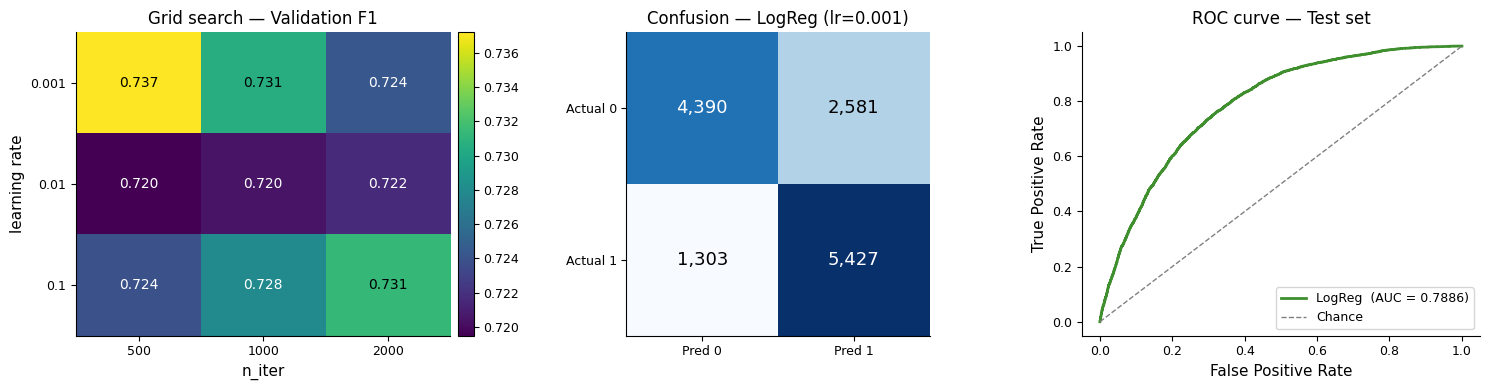

In [16]:
fig = plt.figure(figsize=(15, 4))

# Grid search F1 by (lr, n_iter)
ax = fig.add_subplot(1, 3, 1)
pivot = logreg_grid_df.pivot(index='lr', columns='n_iter', values='f1')
im = ax.imshow(pivot.values, cmap=PALETTE['grid_cmap'], aspect='auto')
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)));   ax.set_yticklabels(pivot.index)
ax.set_xlabel('n_iter'); ax.set_ylabel('learning rate')
ax.set_title('Grid search — Validation F1')
mid = (pivot.values.min() + pivot.values.max()) / 2
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = pivot.values[i, j]
        ax.text(j, i, f'{v:.3f}', ha='center', va='center', fontsize=10,
                color='white' if v < mid else 'black')
plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)

# Confusion matrix
ax = fig.add_subplot(1, 3, 2)
plot_confusion_matrix(logreg_metrics,
                      f'Confusion — LogReg (lr={logreg_cfg["lr"]})',
                      ax=ax)

# ROC
ax = fig.add_subplot(1, 3, 3)
plot_roc(y_test, logreg_y_proba, label='LogReg', color=PALETTE['logreg'], ax=ax)

plt.tight_layout()
plt.show()


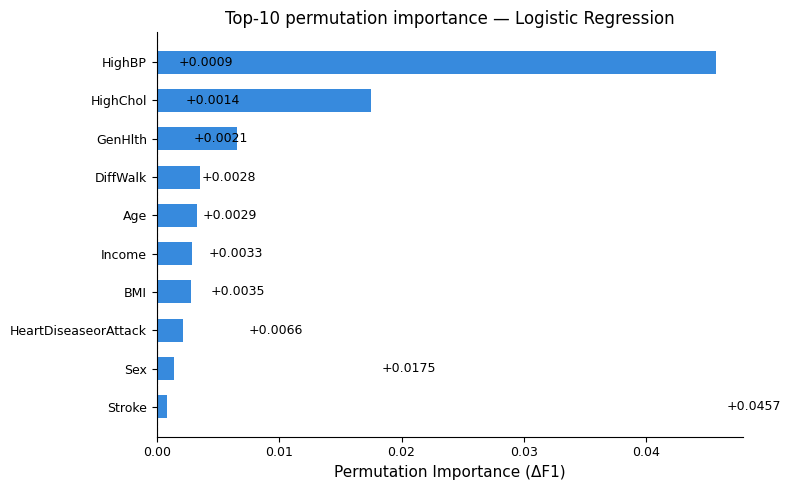

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_top_features(logreg_importances, feature_names,
                  title=f'Top-10 permutation importance — Logistic Regression',
                  ax=ax)
plt.tight_layout()
plt.show()


## 4. K-Nearest Neighbours

### 4.1 Grid search + train (or load cached artifacts)

Grid: `k ∈ {3, 5, 7, 9, 11}` × `metric ∈ {Euclidean, Manhattan}` = 10 configs. Selection on validation F1.


In [18]:
RETRAIN_KNN = False

KNN_ARTIFACTS = {
    'best_config':  f'{MODELS_DIR}/knn_best_config.npy',
    'importances':  f'{MODELS_DIR}/knn_importances.npy',
    'grid_search':  f'{MODELS_DIR}/knn_grid_search.csv',
}

def _knn_grid_search(X_tr, y_tr, X_val, y_val,
                     k_values=(3, 5, 7, 9, 11),
                     metrics_list=('Euclidean', 'Manhattan')):
    results, best_f1, best_cfg = [], -1.0, None
    for met_name in metrics_list:
        for k in k_values:
            t0 = time.time()
            m = KNN(num_neighbors=k, metric=met_name)
            m.fit(X_tr, y_tr)
            y_pred = m.predict(X_val)
            met = compute_metrics(y_val, y_pred)
            elapsed = time.time() - t0
            print(f'  k={k:<2} {met_name:<10} → F1={met["f1"]:.4f}  '
                  f'Acc={met["accuracy"]:.4f}  ({elapsed:.1f}s)')
            results.append({'k': k, 'metric': met_name, **met, 'time_s': elapsed})
            if met['f1'] > best_f1:
                best_f1, best_cfg = met['f1'], {'k': k, 'metric': met_name}
    return best_cfg, results


have_cached = (not RETRAIN_KNN) and all(os.path.exists(p) for p in KNN_ARTIFACTS.values())

if have_cached:
    print('[skip] Loading cached KNN artifacts ...')
    cfg_arr = np.load(KNN_ARTIFACTS['best_config'], allow_pickle=True)
    knn_cfg = {'k': int(cfg_arr[0]), 'metric': str(cfg_arr[1])}
    knn_importances = np.load(KNN_ARTIFACTS['importances'])
    knn_grid_df     = pd.read_csv(KNN_ARTIFACTS['grid_search'])
else:
    print('── KNN grid search ─────────────────────────────────')
    knn_cfg, gs_knn = _knn_grid_search(X_tr, y_tr, X_val, y_val)
    print(f'\n★ Best: k={knn_cfg["k"]}, metric={knn_cfg["metric"]}')
    knn_grid_df = pd.DataFrame(gs_knn).round(4)
    np.save(KNN_ARTIFACTS['best_config'],
            np.array([knn_cfg['k'], knn_cfg['metric']], dtype=object))
    with open(KNN_ARTIFACTS['grid_search'], 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=gs_knn[0].keys())
        writer.writeheader(); writer.writerows(gs_knn)

# KNN is lazy → 'training' is just storing the data. Do this every time.
knn_model = KNN(num_neighbors=knn_cfg['k'], metric=knn_cfg['metric'])
knn_model.fit(X_train, y_train)

# Test predictions
t0 = time.time()
knn_y_pred  = knn_model.predict(X_test)
knn_y_proba = knn_model.predict_proba(X_test)
print(f'\nKNN test inference: {time.time() - t0:.1f}s')

knn_metrics = compute_metrics(y_test, knn_y_pred, knn_y_proba)
print_metrics(knn_metrics, label=f'KNN test  k={knn_cfg["k"]} {knn_cfg["metric"]}')


[skip] Loading cached KNN artifacts ...

KNN test inference: 28.7s

── KNN test  k=5 Euclidean ───────────────────────
  Accuracy  : 0.7041
  Precision : 0.6920
  Recall    : 0.7166
  F1-Score  : 0.7041
  AUC-ROC   : 0.7612
  TP=4823  TN=4824  FP=2147  FN=1907


### 4.2 Permutation importance (or load cached)

In [19]:
if (not RETRAIN_KNN) and os.path.exists(KNN_ARTIFACTS['importances']):
    print('[skip] Loading cached KNN permutation importance ...')
    knn_importances = np.load(KNN_ARTIFACTS['importances'])
else:
    print('── KNN permutation importance (slow — minutes) ─────')
    knn_importances = permutation_importance(
        knn_model, X_test, y_test, feature_names, n_repeats=3, metric='f1',
    )
    np.save(KNN_ARTIFACTS['importances'], knn_importances)


[skip] Loading cached KNN permutation importance ...


### 4.3 Plots — grid search, confusion matrix, ROC, top features

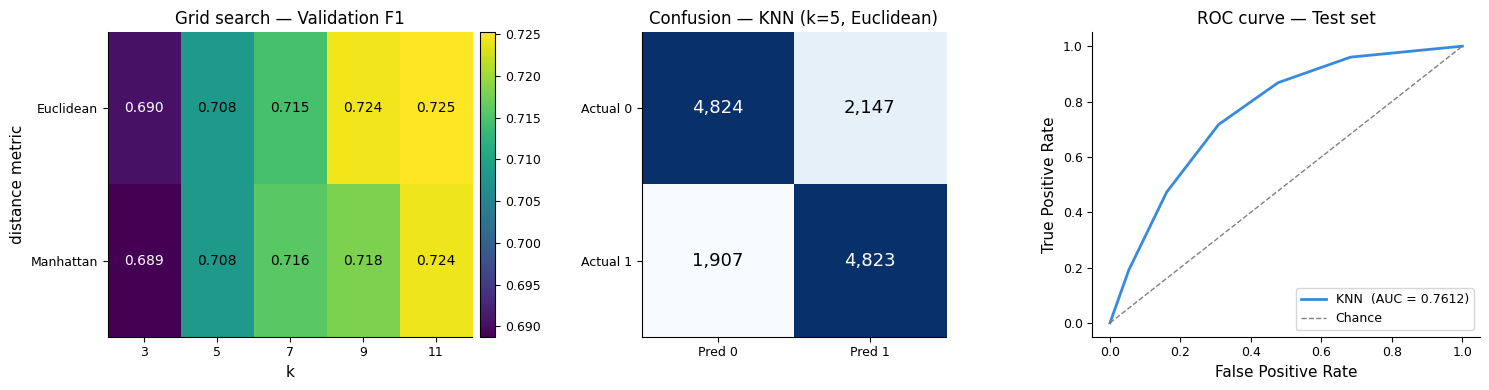

In [20]:
fig = plt.figure(figsize=(15, 4))

# Grid search F1 by (k, metric)
ax = fig.add_subplot(1, 3, 1)
pivot = knn_grid_df.pivot(index='metric', columns='k', values='f1')
im = ax.imshow(pivot.values, cmap=PALETTE['grid_cmap'], aspect='auto')
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)));   ax.set_yticklabels(pivot.index)
ax.set_xlabel('k'); ax.set_ylabel('distance metric')
ax.set_title('Grid search — Validation F1')
mid = (pivot.values.min() + pivot.values.max()) / 2
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = pivot.values[i, j]
        ax.text(j, i, f'{v:.3f}', ha='center', va='center', fontsize=10,
                color='white' if v < mid else 'black')
plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)

# Confusion matrix
ax = fig.add_subplot(1, 3, 2)
plot_confusion_matrix(knn_metrics,
                      f'Confusion — KNN (k={knn_cfg["k"]}, {knn_cfg["metric"]})',
                      ax=ax)

# ROC
ax = fig.add_subplot(1, 3, 3)
plot_roc(y_test, knn_y_proba, label='KNN', color=PALETTE['knn'], ax=ax)

plt.tight_layout()
plt.show()


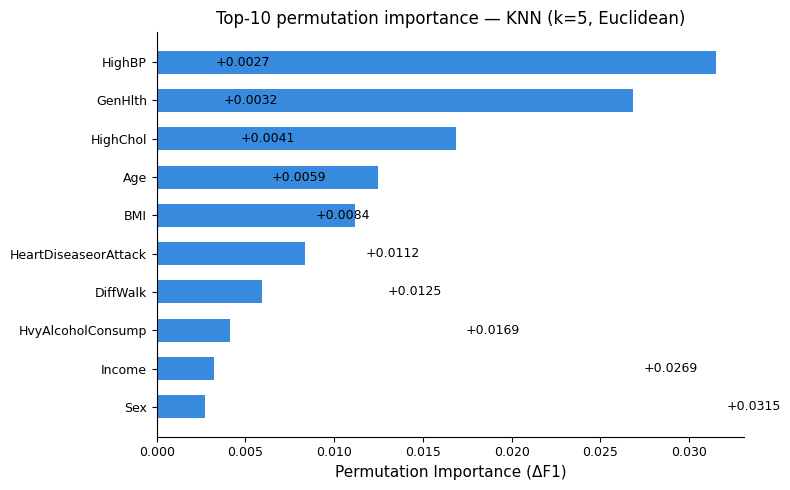

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_top_features(knn_importances, feature_names,
                  title=f'Top-10 permutation importance — KNN '
                        f'(k={knn_cfg["k"]}, {knn_cfg["metric"]})',
                  ax=ax)
plt.tight_layout()
plt.show()


## 5. Artificial Neural Network

### 5.1 Proposal grid search (or load cached)

Proposal grid: `lr ∈ {0.001, 0.01}` × `hidden ∈ {32, 64, 128}` × `epochs ∈ {50, 100, 200}` = 18 configs (1-layer, fixed batch=256, wd=1e-4, no early stop). This usually takes a few minutes — set `RETRAIN_ANN = True` to force.


In [22]:
RETRAIN_ANN = False

ANN_ARTIFACTS = {
    'best_config':  f'{MODELS_DIR}/ann_best_config.npy',
    'weights':      f'{MODELS_DIR}/ann_weights.npz',
    'importances':  f'{MODELS_DIR}/ann_importances.npy',
    'grid_search':  f'{MODELS_DIR}/ann_grid_search.csv',
    'leaderboard':  f'{MODELS_DIR}/ann_leaderboard.csv',
    'train_loss':   f'{MODELS_DIR}/ann_train_loss.npy',
    'val_loss':     f'{MODELS_DIR}/ann_val_loss.npy',
}

def _ann_proposal_grid(X_tr, y_tr, X_val, y_val,
                       lr_values=(0.001, 0.01),
                       hidden_values=(32, 64, 128),
                       epoch_values=(50, 100, 200)):
    results, best_f1, best_cfg = [], -1.0, None
    for lr in lr_values:
        for hd in hidden_values:
            for n_ep in epoch_values:
                t0 = time.time()
                m = ANN(input_dim=X_tr.shape[1], hidden_dim=hd,
                        learning_rate=lr, epochs=n_ep, early_stopping=False)
                m.fit(X_tr, y_tr)
                y_pred = m.predict(X_val)
                met = compute_metrics(y_val, y_pred)
                elapsed = time.time() - t0
                print(f'  lr={lr:<6} hd={hd:<4} ep={n_ep:<4} → '
                      f'F1={met["f1"]:.4f}  Acc={met["accuracy"]:.4f}  ({elapsed:.1f}s)')
                results.append({'lr': lr, 'hidden_dim': hd, 'epochs': n_ep,
                                **met, 'time_s': elapsed})
                if met['f1'] > best_f1:
                    best_f1 = met['f1']
                    best_cfg = {'lr': lr, 'hidden_dim': hd, 'epochs': n_ep}
    return best_cfg, results


if (not RETRAIN_ANN) and os.path.exists(ANN_ARTIFACTS['grid_search']):
    print('[skip] Loading cached ANN proposal-grid CSV ...')
    ann_grid_df = pd.read_csv(ANN_ARTIFACTS['grid_search'])
    proposal_best = ann_grid_df.sort_values('f1', ascending=False).iloc[0]
    print(f'★ Best (cached): lr={proposal_best["lr"]}, '
          f'hidden={int(proposal_best["hidden_dim"])}, epochs={int(proposal_best["epochs"])}, '
          f'F1={proposal_best["f1"]:.4f}')
else:
    print('── ANN proposal grid search ────────────────────────')
    t0 = time.time()
    cfg, gs_ann = _ann_proposal_grid(X_tr, y_tr, X_val, y_val)
    print(f'\nGrid search took {time.time() - t0:.1f}s  ★ best={cfg}')
    ann_grid_df = pd.DataFrame(gs_ann).round(4)
    with open(ANN_ARTIFACTS['grid_search'], 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=gs_ann[0].keys())
        writer.writeheader(); writer.writerows(gs_ann)

ann_grid_df.sort_values('f1', ascending=False).head(5).reset_index(drop=True)


[skip] Loading cached ANN proposal-grid CSV ...
★ Best (cached): lr=0.01, hidden=128, epochs=100, F1=0.7536


,lr,hidden_dim,epochs,accuracy,precision,recall,f1,TP,TN,FP,FN,time_s
0,0.01,128,100,0.747856,0.727288,0.781909,0.753610,4227,3971,1585,1179,4.466451
1,0.01,32,50,0.746944,0.725188,0.783944,0.753422,4238,3950,1606,1168,1.391046
2,0.01,64,100,0.747583,0.728327,0.778579,0.752615,4209,3986,1570,1197,3.230050
3,0.01,64,50,0.748404,0.731712,0.773400,0.751978,4181,4023,1533,1225,1.560391
4,0.01,32,100,0.746579,0.726865,0.778764,0.751920,4210,3974,1582,1196,2.971568


### 5.2 Plot — proposal grid heatmaps (validation F1 across `lr × hidden`)

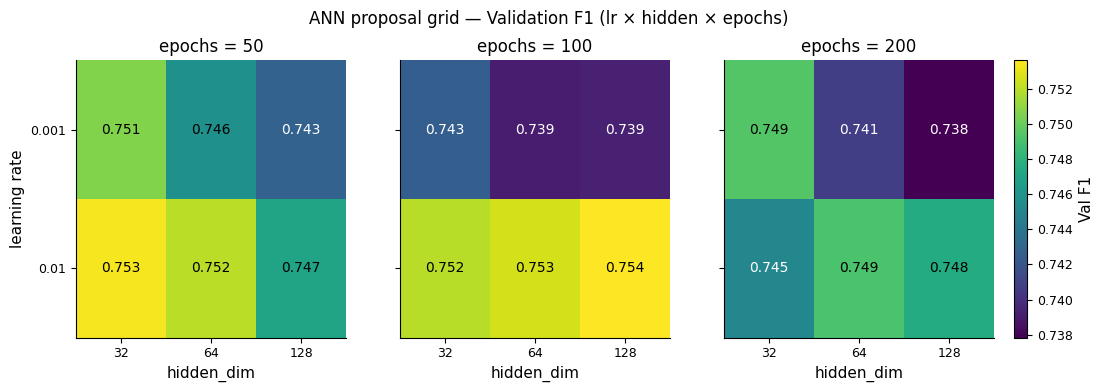

In [23]:
metric_to_plot = 'f1'
epochs_sorted  = sorted(ann_grid_df['epochs'].unique())

fig, axes = plt.subplots(1, len(epochs_sorted),
                         figsize=(4.2 * len(epochs_sorted), 3.6),
                         sharey=True)
if len(epochs_sorted) == 1:
    axes = [axes]
vmin, vmax = ann_grid_df[metric_to_plot].min(), ann_grid_df[metric_to_plot].max()

for ax, ep in zip(axes, epochs_sorted):
    sub   = ann_grid_df[ann_grid_df['epochs'] == ep]
    pivot = sub.pivot(index='lr', columns='hidden_dim', values=metric_to_plot)
    im = ax.imshow(pivot.values, cmap=PALETTE['grid_cmap'],
                   vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)));   ax.set_yticklabels(pivot.index)
    ax.set_xlabel('hidden_dim')
    if ax is axes[0]:
        ax.set_ylabel('learning rate')
    ax.set_title(f'epochs = {int(ep)}')
    mid = (vmin + vmax) / 2
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            v = pivot.values[i, j]
            ax.text(j, i, f'{v:.3f}', ha='center', va='center',
                    color='white' if v < mid else 'black', fontsize=10)

fig.colorbar(im, ax=axes, label=f'Val {metric_to_plot.upper()}',
             fraction=0.04, pad=0.02)
plt.suptitle('ANN proposal grid — Validation F1 (lr × hidden × epochs)',
             fontsize=12, y=1.02)
plt.show()


### 5.3 Refined search (1-layer + 2-layer leaderboard) — or load cached

Beyond the proposal grid, we sweep two regularisation-flavoured axes (`weight_decay`, `batch_size`) for the 1-layer network plus a small 2-layer (`ANN2`) sweep, then stack both into one leaderboard ranked by validation F1. Skipped if `models/ann_leaderboard.csv` already exists.


In [24]:
def _refined_1l(X_tr, y_tr, X_val, y_val):
    LRS, HIDS, WDS, BS = (0.005, 0.01, 0.02), (128, 256), (0.0, 1e-4, 1e-3), (64, 256)
    results = []
    for lr in LRS:
        for hd in HIDS:
            for wd in WDS:
                for bs in BS:
                    t0 = time.time()
                    m = ANN(input_dim=X_tr.shape[1], hidden_dim=hd,
                            learning_rate=lr, epochs=200, batch_size=bs,
                            weight_decay=wd, early_stopping=True, patience=15)
                    m.fit(X_tr, y_tr, X_val, y_val)
                    met = compute_metrics(y_val, m.predict(X_val))
                    eu  = len(m.train_loss_history)
                    print(f'  1L lr={lr:<6} hd={hd:<4} wd={wd:<6} bs={bs:<3} → '
                          f'F1={met["f1"]:.4f} stop@{eu} ({time.time()-t0:.1f}s)')
                    results.append({'arch': '1L', 'lr': lr, 'hidden': hd,
                                    'wd': wd, 'batch_size': bs,
                                    'epochs_used': eu, **met,
                                    'time_s': time.time() - t0})
    return results


def _refined_2l(X_tr, y_tr, X_val, y_val):
    DIMS, LRS, WDS = ((128, 64), (256, 128), (256, 64)), (0.005, 0.01), (0.0, 1e-4)
    results = []
    for hd in DIMS:
        for lr in LRS:
            for wd in WDS:
                t0 = time.time()
                m = ANN2(input_dim=X_tr.shape[1], hidden_dims=hd,
                         learning_rate=lr, epochs=200, batch_size=128,
                         weight_decay=wd, early_stopping=True, patience=15)
                m.fit(X_tr, y_tr, X_val, y_val)
                met = compute_metrics(y_val, m.predict(X_val))
                eu  = len(m.train_loss_history)
                print(f'  2L hd={str(hd):<12} lr={lr:<6} wd={wd:<6} → '
                      f'F1={met["f1"]:.4f} stop@{eu} ({time.time()-t0:.1f}s)')
                results.append({'arch': '2L', 'lr': lr, 'hidden': str(hd),
                                'wd': wd, 'batch_size': 128,
                                'epochs_used': eu, **met,
                                'time_s': time.time() - t0})
    return results


if (not RETRAIN_ANN) and os.path.exists(ANN_ARTIFACTS['leaderboard']):
    print('[skip] Loading cached leaderboard ...')
    leaderboard = pd.read_csv(ANN_ARTIFACTS['leaderboard'])
else:
    print('── 1-layer refined sweep (36 configs) ──────────────')
    r1 = _refined_1l(X_tr, y_tr, X_val, y_val)
    print('\n── 2-layer sweep (12 configs) ──────────────────────')
    r2 = _refined_2l(X_tr, y_tr, X_val, y_val)
    leaderboard = pd.DataFrame(r1 + r2).round(4)
    leaderboard.to_csv(ANN_ARTIFACTS['leaderboard'], index=False)

leaderboard_sorted = leaderboard.sort_values('f1', ascending=False).reset_index(drop=True)
print(f'\n★ Global winner: arch={leaderboard_sorted.iloc[0]["arch"]}, '
      f'hidden={leaderboard_sorted.iloc[0]["hidden"]}, '
      f'lr={leaderboard_sorted.iloc[0]["lr"]}, '
      f'F1={leaderboard_sorted.iloc[0]["f1"]:.4f}')

leaderboard_sorted.head(10)[
    ['arch', 'hidden', 'lr', 'wd', 'batch_size', 'epochs_used',
     'f1', 'accuracy', 'precision', 'recall']
]


[skip] Loading cached leaderboard ...

★ Global winner: arch=2L, hidden=(128, 64), lr=0.01, F1=0.7590


,arch,hidden,lr,wd,batch_size,epochs_used,f1,accuracy,precision,recall
0,2L,"(128, 64)",0.010,0.0000,128,23,0.7590,0.7453,0.7115,0.8134
1,2L,"(128, 64)",0.005,0.0001,128,44,0.7587,0.7487,0.7204,0.8013
2,2L,"(256, 64)",0.010,0.0001,128,45,0.7585,0.7458,0.7134,0.8097
3,1L,128,0.010,0.0010,256,63,0.7583,0.7482,0.7200,0.8010
4,1L,256,0.020,0.0010,64,31,0.7580,0.7449,0.7122,0.8102
5,2L,"(128, 64)",0.010,0.0001,128,39,0.7578,0.7486,0.7219,0.7974
6,2L,"(256, 128)",0.005,0.0001,128,34,0.7571,0.7463,0.7173,0.8015
7,1L,128,0.020,0.0010,256,36,0.7570,0.7460,0.7167,0.8021
8,1L,128,0.020,0.0001,256,41,0.7570,0.7477,0.7208,0.7971
9,1L,128,0.010,0.0000,256,32,0.7569,0.7450,0.7144,0.8047


### 5.4 Top-15 leaderboard chart (1-layer vs 2-layer)

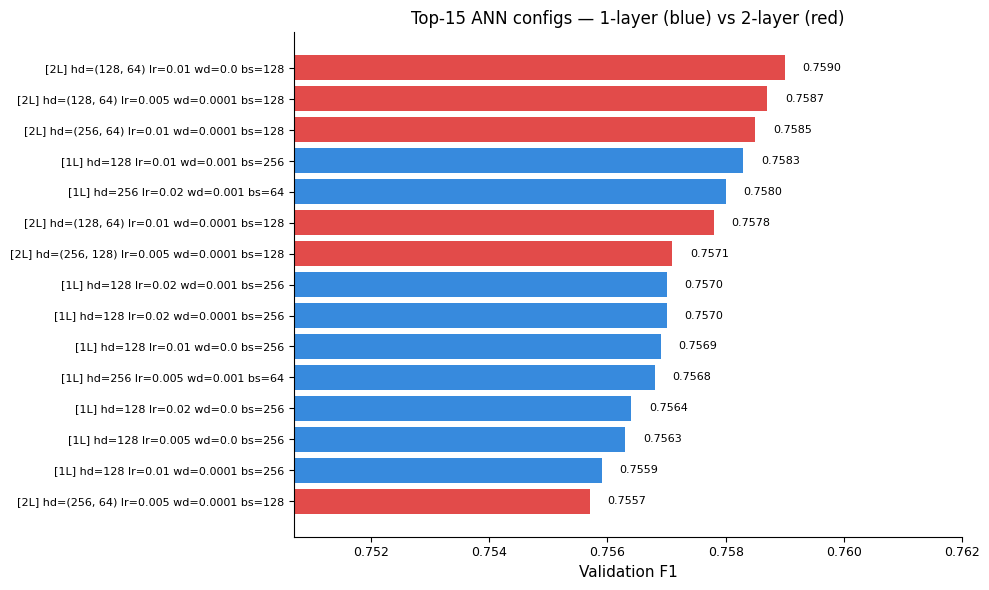

In [25]:
top15  = leaderboard_sorted.head(15).copy()
labels = [f"[{r.arch}] hd={r.hidden} lr={r.lr} wd={r.wd} bs={r.batch_size}"
          for r in top15.itertuples()]
colors = [PALETTE['knn'] if a == '1L' else PALETTE['ann'] for a in top15['arch']]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(range(len(top15))[::-1], top15['f1'], color=colors)
ax.set_yticks(range(len(top15))[::-1])
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel('Validation F1')
ax.set_xlim(top15['f1'].min() - 0.005, top15['f1'].max() + 0.003)
ax.set_title('Top-15 ANN configs — 1-layer (blue) vs 2-layer (red)')
for bar, val in zip(bars, top15['f1']):
    ax.text(val + 0.0003, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()


### 5.5 Final ANN — train winner + tune decision threshold (or load cached)

Re-trains the leaderboard winner on the train split with early stopping, then sweeps the decision threshold over `predict_proba(X_val)` to maximise validation F1. The default threshold (0.5) almost never gives the best F1.


In [26]:
def _build_winner_model(arch, hidden, lr, wd, batch_size,
                        epochs=300, patience=20, verbose=False):
    if arch == '2L':
        hd_tuple = eval(hidden) if isinstance(hidden, str) else tuple(hidden)
        return ANN2(input_dim=X_train.shape[1], hidden_dims=hd_tuple,
                    learning_rate=lr, epochs=epochs, batch_size=int(batch_size),
                    weight_decay=wd, early_stopping=True, patience=patience,
                    verbose=verbose)
    return ANN(input_dim=X_train.shape[1], hidden_dim=int(hidden),
               learning_rate=lr, epochs=epochs, batch_size=int(batch_size),
               weight_decay=wd, early_stopping=True, patience=patience,
               verbose=verbose)


have_cached = (
    (not RETRAIN_ANN)
    and all(os.path.exists(p) for p in [
        ANN_ARTIFACTS['weights'], ANN_ARTIFACTS['best_config'],
    ])
)

if have_cached:
    print('[skip] Loading cached ANN final model ...')
    cfg_arr = np.load(ANN_ARTIFACTS['best_config'], allow_pickle=True)
    BEST_ARCH      = str(cfg_arr[0])
    BEST_HIDDEN    = cfg_arr[1]
    BEST_LR        = float(cfg_arr[2])
    BEST_WD        = float(cfg_arr[3])
    BEST_BATCH     = int(cfg_arr[4])
    BEST_EPOCHS    = int(cfg_arr[5])
    BEST_THRESHOLD = float(cfg_arr[6])

    final_model = _build_winner_model(BEST_ARCH, BEST_HIDDEN, BEST_LR,
                                      BEST_WD, BEST_BATCH,
                                      epochs=BEST_EPOCHS, verbose=False)
    weights = np.load(ANN_ARTIFACTS['weights'])
    for k in final_model.net.params:
        final_model.net.params[k] = weights[k]

    # Loss curves are optional — only used by the training-curve plot below.
    if os.path.exists(ANN_ARTIFACTS['train_loss']):
        final_model.train_loss_history = np.load(ANN_ARTIFACTS['train_loss']).tolist()
    if os.path.exists(ANN_ARTIFACTS['val_loss']):
        final_model.val_loss_history   = np.load(ANN_ARTIFACTS['val_loss']).tolist()

    # Re-derive the threshold sweep curve for the plot below
    val_proba    = final_model.predict_proba(X_val)
    thresh_grid  = np.linspace(0.05, 0.95, 91)
    f1_curve     = np.array([compute_metrics(y_val, (val_proba >= t).astype(np.float64))['f1']
                             for t in thresh_grid])
    default_f1   = compute_metrics(y_val, (val_proba >= 0.5).astype(np.float64))['f1']
else:
    gw = leaderboard_sorted.iloc[0]
    BEST_ARCH      = gw['arch']
    BEST_HIDDEN    = gw['hidden']
    BEST_LR        = float(gw['lr'])
    BEST_WD        = float(gw['wd'])
    BEST_BATCH     = int(gw['batch_size'])
    BEST_EPOCHS    = 300

    print('── Training final ANN with early stopping ──────────')
    final_model = _build_winner_model(BEST_ARCH, BEST_HIDDEN, BEST_LR,
                                      BEST_WD, BEST_BATCH,
                                      epochs=BEST_EPOCHS, verbose=True)
    t0 = time.time()
    final_model.fit(X_tr, y_tr, X_val, y_val)
    print(f'\nStopped after {len(final_model.train_loss_history)} epochs '
          f'({time.time()-t0:.1f}s)')

    print('\n── Threshold sweep on validation set ───────────────')
    val_proba    = final_model.predict_proba(X_val)
    thresh_grid  = np.linspace(0.05, 0.95, 91)
    f1_curve     = np.array([compute_metrics(y_val, (val_proba >= t).astype(np.float64))['f1']
                             for t in thresh_grid])
    BEST_THRESHOLD = float(thresh_grid[int(np.argmax(f1_curve))])
    default_f1     = compute_metrics(y_val, (val_proba >= 0.5).astype(np.float64))['f1']
    print(f'Default threshold (0.50): F1={default_f1:.4f}')
    print(f'Tuned   threshold ({BEST_THRESHOLD:.2f}): F1={f1_curve.max():.4f}')

    # Persist artifacts
    if BEST_ARCH == '2L':
        np.savez(ANN_ARTIFACTS['weights'],
                 W1=final_model.net.params['W1'], b1=final_model.net.params['b1'],
                 W2=final_model.net.params['W2'], b2=final_model.net.params['b2'],
                 W3=final_model.net.params['W3'], b3=final_model.net.params['b3'])
    else:
        np.savez(ANN_ARTIFACTS['weights'],
                 W1=final_model.net.params['W1'], b1=final_model.net.params['b1'],
                 W2=final_model.net.params['W2'], b2=final_model.net.params['b2'])
    np.save(ANN_ARTIFACTS['best_config'],
            np.array([BEST_ARCH, BEST_HIDDEN, BEST_LR, BEST_WD,
                      BEST_BATCH, BEST_EPOCHS, BEST_THRESHOLD], dtype=object))
    np.save(ANN_ARTIFACTS['train_loss'], np.array(final_model.train_loss_history))
    np.save(ANN_ARTIFACTS['val_loss'],   np.array(final_model.val_loss_history))

print(f'\nFinal config: arch={BEST_ARCH}  hidden={BEST_HIDDEN}  lr={BEST_LR}  '
      f'wd={BEST_WD}  batch={BEST_BATCH}  threshold={BEST_THRESHOLD:.3f}')


[skip] Loading cached ANN final model ...

Final config: arch=2L  hidden=(128, 64)  lr=0.01  wd=0.0  batch=128  threshold=0.390


### 5.6 Plots — training curve + threshold sweep

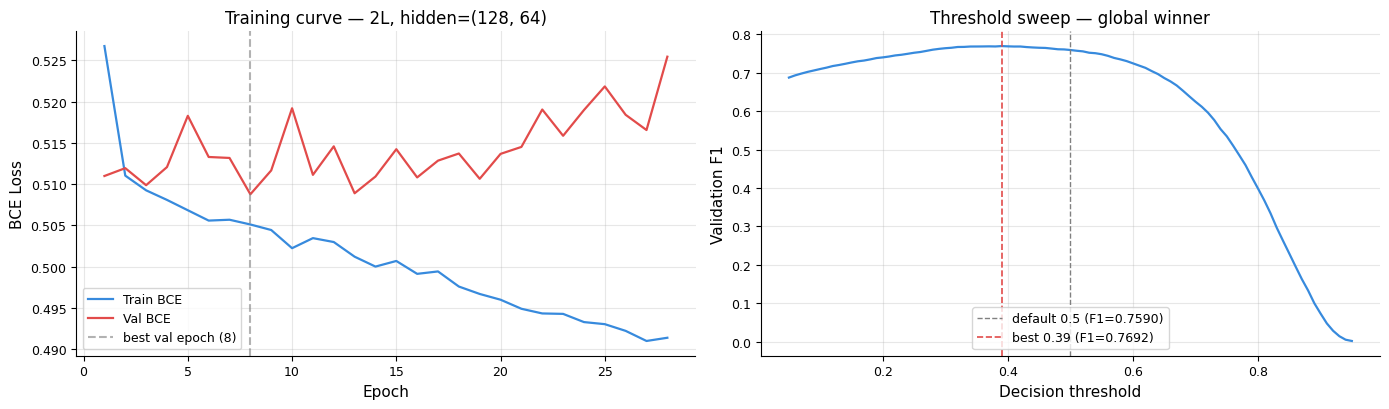

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))

# Training curves (only if loss history is available — cached weights may not have it)
ax = axes[0]
if final_model.train_loss_history:
    epochs_axis = range(1, len(final_model.train_loss_history) + 1)
    ax.plot(epochs_axis, final_model.train_loss_history,
            label='Train BCE', linewidth=1.6, color=PALETTE['knn'])
    if final_model.val_loss_history:
        ax.plot(range(1, len(final_model.val_loss_history) + 1),
                final_model.val_loss_history,
                label='Val BCE', linewidth=1.6, color=PALETTE['ann'])
        best_ep = int(np.argmin(final_model.val_loss_history)) + 1
        ax.axvline(best_ep, color=PALETTE['ref'], linestyle='--', alpha=0.6,
                   label=f'best val epoch ({best_ep})')
    ax.set_xlabel('Epoch'); ax.set_ylabel('BCE Loss')
    ax.set_title(f'Training curve — {BEST_ARCH}, hidden={BEST_HIDDEN}')
    ax.grid(alpha=0.3)
    ax.legend()
else:
    ax.text(0.5, 0.5, 'No loss history available\n(cached weights, not retrained)',
            ha='center', va='center', transform=ax.transAxes,
            fontsize=11, color=PALETTE['ref'])
    ax.set_title(f'Training curve — {BEST_ARCH} (skipped)')
    ax.set_xticks([]); ax.set_yticks([])

# Threshold sweep
ax = axes[1]
ax.plot(thresh_grid, f1_curve, color=PALETTE['knn'], linewidth=1.6)
ax.axvline(0.5, color=PALETTE['ref'], linestyle='--', linewidth=1,
           label=f'default 0.5 (F1={default_f1:.4f})')
ax.axvline(BEST_THRESHOLD, color=PALETTE['ann'], linestyle='--', linewidth=1.2,
           label=f'best {BEST_THRESHOLD:.2f} (F1={f1_curve.max():.4f})')
ax.set_xlabel('Decision threshold'); ax.set_ylabel('Validation F1')
ax.set_title('Threshold sweep — global winner')
ax.grid(alpha=0.3)
ax.legend(loc='lower center')

plt.tight_layout()
plt.show()


### 5.7 Test-set evaluation (default vs tuned threshold)

In [28]:
ann_y_proba = final_model.predict_proba(X_test)
y_pred_default = (ann_y_proba >= 0.5).astype(np.float64)
ann_y_pred     = (ann_y_proba >= BEST_THRESHOLD).astype(np.float64)

ann_metrics_default = compute_metrics(y_test, y_pred_default, ann_y_proba)
ann_metrics         = compute_metrics(y_test, ann_y_pred,     ann_y_proba)

results_df = pd.DataFrame([
    {
        'Variant':   'threshold = 0.50 (default)',
        'Accuracy':  round(ann_metrics_default['accuracy'],  4),
        'Precision': round(ann_metrics_default['precision'], 4),
        'Recall':    round(ann_metrics_default['recall'],    4),
        'F1-Score':  round(ann_metrics_default['f1'],        4),
        'AUC-ROC':   round(ann_metrics_default['auc_roc'],   4),
    },
    {
        'Variant':   f'threshold = {BEST_THRESHOLD:.2f} (tuned)',
        'Accuracy':  round(ann_metrics['accuracy'],  4),
        'Precision': round(ann_metrics['precision'], 4),
        'Recall':    round(ann_metrics['recall'],    4),
        'F1-Score':  round(ann_metrics['f1'],        4),
        'AUC-ROC':   round(ann_metrics['auc_roc'],   4),
    },
])
results_df


,Variant,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,threshold = 0.50 (default),0.7515,0.7179,0.8140,0.7629,0.827
1,threshold = 0.39 (tuned),0.7417,0.6841,0.8808,0.7701,0.827


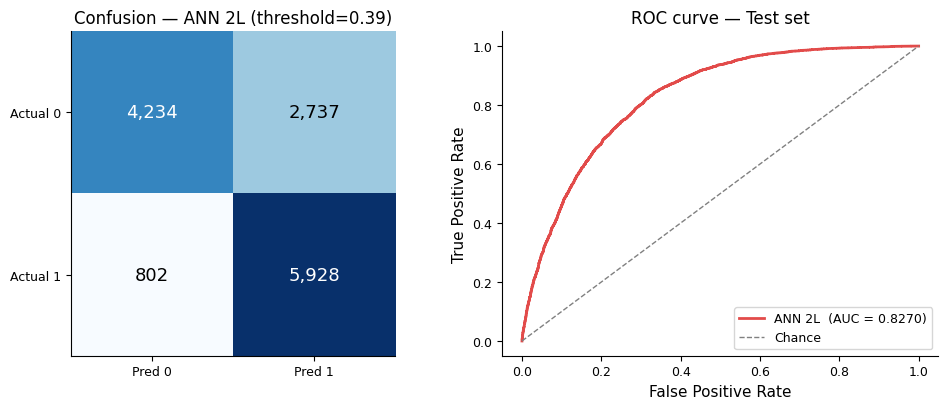

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
plot_confusion_matrix(ann_metrics,
                      f'Confusion — ANN {BEST_ARCH} (threshold={BEST_THRESHOLD:.2f})',
                      ax=axes[0])
plot_roc(y_test, ann_y_proba, label=f'ANN {BEST_ARCH}',
         color=PALETTE['ann'], ax=axes[1])
plt.tight_layout()
plt.show()


### 5.8 Permutation importance + top-10 features

[skip] Loading cached ANN permutation importance ...


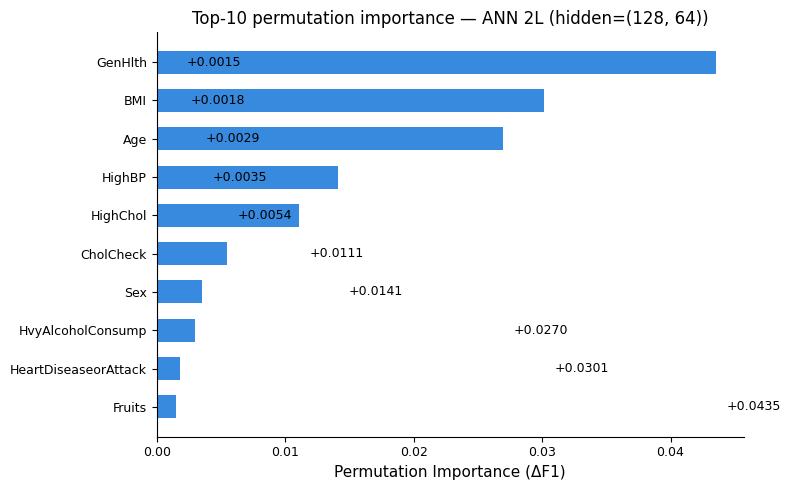

In [30]:
if (not RETRAIN_ANN) and os.path.exists(ANN_ARTIFACTS['importances']):
    print('[skip] Loading cached ANN permutation importance ...')
    ann_importances = np.load(ANN_ARTIFACTS['importances'])
else:
    print('── ANN permutation importance ──────────────────────')
    ann_importances = permutation_importance(
        final_model, X_test, y_test, feature_names, n_repeats=3, metric='f1',
    )
    np.save(ANN_ARTIFACTS['importances'], ann_importances)

fig, ax = plt.subplots(figsize=(8, 5))
plot_top_features(ann_importances, feature_names,
                  title=f'Top-10 permutation importance — ANN {BEST_ARCH} '
                        f'(hidden={BEST_HIDDEN})',
                  ax=ax)
plt.tight_layout()
plt.show()


## 6. Cross-Model Comparison

### 6.1 Test-set metrics

In [31]:
summary_df = pd.DataFrame([
    {
        'Model':     f'Logistic Regression (lr={logreg_cfg["lr"]}, n_iter={logreg_cfg["n_iter"]})',
        'Accuracy':  round(logreg_metrics['accuracy'],  4),
        'Precision': round(logreg_metrics['precision'], 4),
        'Recall':    round(logreg_metrics['recall'],    4),
        'F1-Score':  round(logreg_metrics['f1'],        4),
        'AUC-ROC':   round(logreg_metrics['auc_roc'],   4),
    },
    {
        'Model':     f'KNN (k={knn_cfg["k"]}, {knn_cfg["metric"]})',
        'Accuracy':  round(knn_metrics['accuracy'],  4),
        'Precision': round(knn_metrics['precision'], 4),
        'Recall':    round(knn_metrics['recall'],    4),
        'F1-Score':  round(knn_metrics['f1'],        4),
        'AUC-ROC':   round(knn_metrics['auc_roc'],   4),
    },
    {
        'Model':     f'ANN {BEST_ARCH} (hidden={BEST_HIDDEN}, threshold={BEST_THRESHOLD:.2f})',
        'Accuracy':  round(ann_metrics['accuracy'],  4),
        'Precision': round(ann_metrics['precision'], 4),
        'Recall':    round(ann_metrics['recall'],    4),
        'F1-Score':  round(ann_metrics['f1'],        4),
        'AUC-ROC':   round(ann_metrics['auc_roc'],   4),
    },
])
summary_df


,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,"Logistic Regression (lr=0.001, n_iter=500)",0.7165,0.6777,0.8064,0.7365,0.7886
1,"KNN (k=5, Euclidean)",0.7041,0.6920,0.7166,0.7041,0.7612
2,"ANN 2L (hidden=(128, 64), threshold=0.39)",0.7417,0.6841,0.8808,0.7701,0.8270


### 6.2 Metric comparison bar chart + ROC overlay

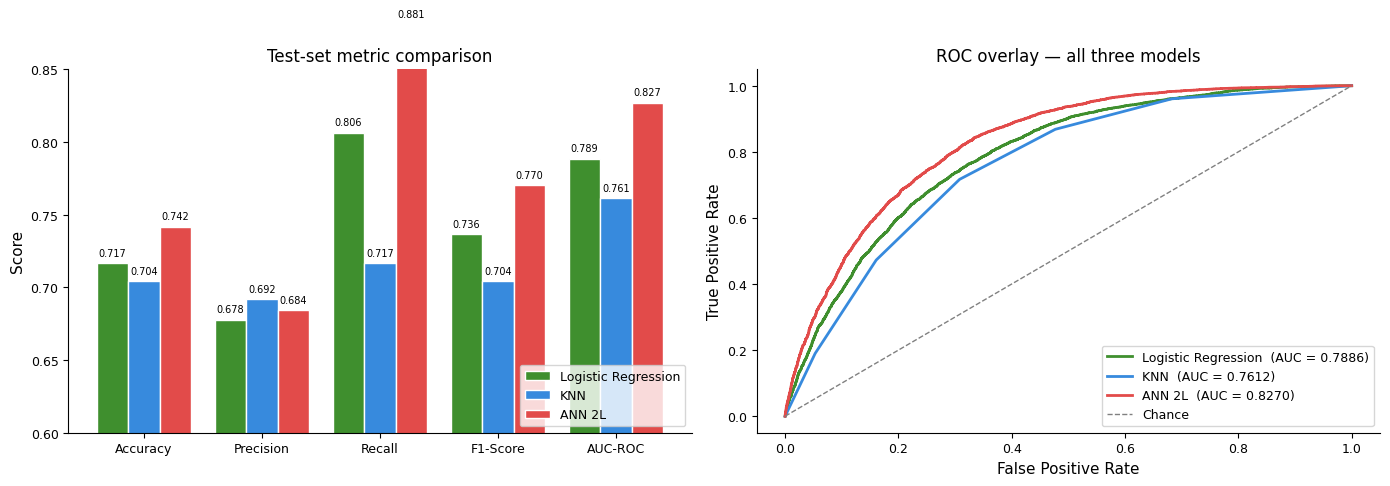

In [32]:
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
metric_keys   = ['accuracy', 'precision', 'recall', 'f1', 'auc_roc']
models = [
    ('Logistic Regression', logreg_metrics, PALETTE['logreg']),
    ('KNN',                 knn_metrics,    PALETTE['knn']),
    (f'ANN {BEST_ARCH}',    ann_metrics,    PALETTE['ann']),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of all 5 metrics
ax = axes[0]
n_models = len(models)
x = np.arange(len(metric_labels))
width = 0.8 / n_models
for i, (name, m, c) in enumerate(models):
    vals = [m[k] for k in metric_keys]
    bars = ax.bar(x + (i - (n_models - 1) / 2) * width, vals, width,
                  label=name, color=c, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.005,
                f'{v:.3f}', ha='center', fontsize=7)
ax.set_xticks(x); ax.set_xticklabels(metric_labels)
ax.set_ylim(0.6, 0.85)
ax.set_ylabel('Score')
ax.set_title('Test-set metric comparison')
ax.legend(loc='lower right')

# ROC overlay
ax = axes[1]
for (name, _, c), proba in zip(
    models,
    [logreg_y_proba, knn_y_proba, ann_y_proba],
):
    fprs, tprs = roc_points(y_test, proba)
    auc = _auc_roc(y_test, proba)
    ax.plot(fprs, tprs, color=c, linewidth=2, label=f'{name}  (AUC = {auc:.4f})')
ax.plot([0, 1], [0, 1], color=PALETTE['ref'], linestyle='--', linewidth=1, label='Chance')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC overlay — all three models')
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()


### 6.3 Permutation feature importance — heatmap across models

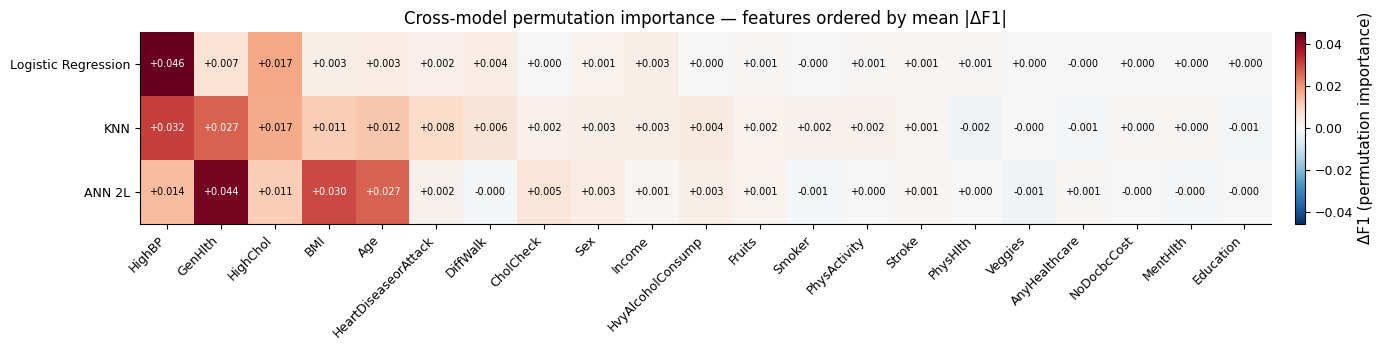

In [33]:
imp_matrix = np.vstack([logreg_importances, knn_importances, ann_importances])
model_names = ['Logistic Regression', 'KNN', f'ANN {BEST_ARCH}']

# Order columns by mean |importance| across models, descending — most useful features on the left
order = np.argsort(np.mean(np.abs(imp_matrix), axis=0))[::-1]
ordered_features = [feature_names[i] for i in order]
imp_ordered = imp_matrix[:, order]

vmax = np.max(np.abs(imp_ordered))

fig, ax = plt.subplots(figsize=(14, 3.6))
im = ax.imshow(imp_ordered, cmap=PALETTE['corr_cmap'], vmin=-vmax, vmax=vmax, aspect='auto')
ax.set_xticks(range(len(ordered_features)))
ax.set_xticklabels(ordered_features, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(model_names)))
ax.set_yticklabels(model_names)
plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02, label='ΔF1 (permutation importance)')
ax.set_title('Cross-model permutation importance — features ordered by mean |ΔF1|')
for i in range(imp_ordered.shape[0]):
    for j in range(imp_ordered.shape[1]):
        v = imp_ordered[i, j]
        ax.text(j, i, f'{v:+.3f}', ha='center', va='center', fontsize=7,
                color='white' if abs(v) > vmax * 0.55 else 'black')
plt.tight_layout()
plt.show()


### 6.4 Top-10 feature agreement (side-by-side bar charts)

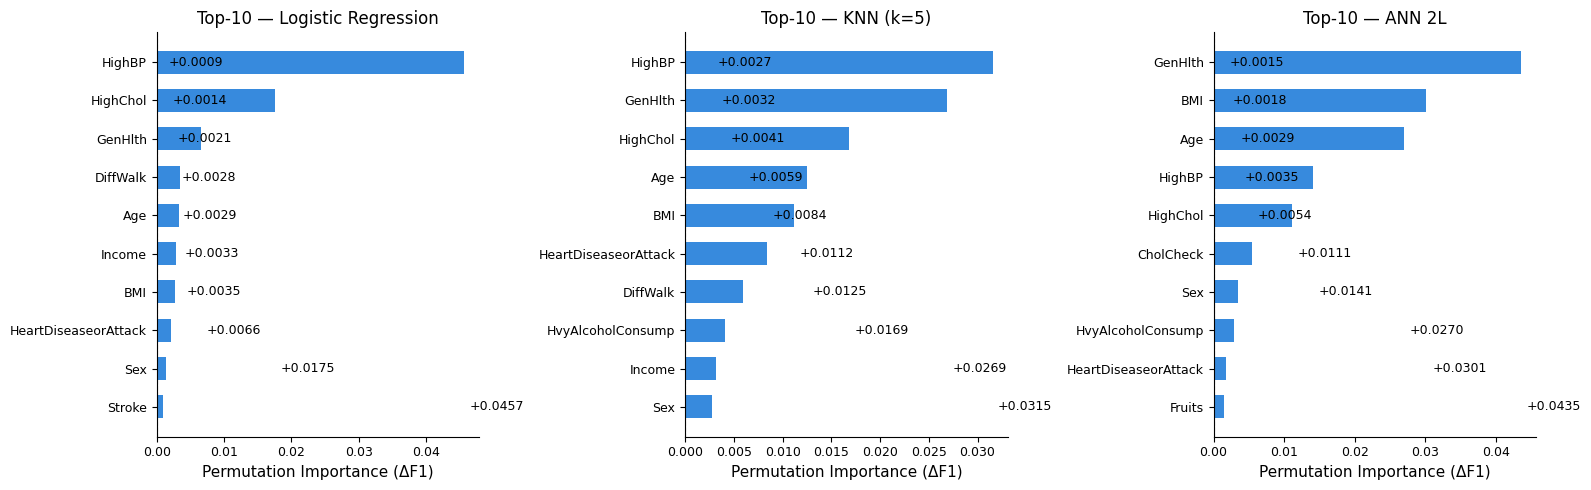

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=False)
plot_top_features(logreg_importances, feature_names,
                  title='Top-10 — Logistic Regression', ax=axes[0])
plot_top_features(knn_importances, feature_names,
                  title=f'Top-10 — KNN (k={knn_cfg["k"]})', ax=axes[1])
plot_top_features(ann_importances, feature_names,
                  title=f'Top-10 — ANN {BEST_ARCH}', ax=axes[2])
plt.tight_layout()
plt.show()


## 7. Summary

This notebook is the full pipeline in one place — preprocessing, three NumPy-only models, evaluation, and cross-model feature-importance comparison.

**Reproducing this notebook:**

| To re-run … | Set this flag to `True` | Or delete these files |
|---|---|---|
| Preprocessing | `RERUN_PREPROCESS` | `models/{X,y}_{train,test}.npy`, `feat_min/max.npy`, `feature_names.npy` |
| Logistic Regression | `RETRAIN_LOGREG` | `models/logreg_*.npy`, `models/logreg_grid_search.csv` |
| KNN | `RETRAIN_KNN` | `models/knn_*.npy`, `models/knn_grid_search.csv` |
| ANN | `RETRAIN_ANN` | `models/ann_*.npy/.npz`, `models/ann_*_search.csv`, `models/ann_leaderboard.csv` |

**Notes on what's expected:**

- Public benchmarks on this BRFSS 2015 50/50 split typically land around **F1 = 0.74–0.78** for traditional ML.
- Threshold tuning is the highest-leverage knob inside this notebook's scope; without it the ANN's F1 drops back into the LogReg/KNN range.
- Top features by permutation importance — `HighBP`, `GenHlth`, `BMI`, `Age`, `HighChol` — are consistent with known clinical risk factors for Type 2 diabetes and tend to agree across all three models.
- KNN's permutation-importance pass is the slowest cell in the notebook (full test-set re-prediction × 21 features × `n_repeats`). The cached `knn_importances.npy` makes re-runs near-instant.
